In [1]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ============================================================
# LOAD MATRICES
# ============================================================

project_root = Path.cwd().parent

data_dir = project_root / "data"

# ------------------------------------------------------------
# LOAD MATRICES
# ------------------------------------------------------------

A = np.load(data_dir / "A.npy")

print("A shape =", A.shape)

A shape = (18, 7)


In [3]:
# ============================================================
# AMBIENT FIELD (mG)
# ============================================================

B_ambient = np.array([

    -283.38,
     106.79,
    -381.21
])

In [4]:
# ============================================================
# REDUCED MATRIX
# ============================================================

A_red = np.column_stack([

    A[:,0],              # X1
    A[:,1],              # X2
    A[:,2],              # X3

    A[:,3] + A[:,4],     # Y grouped

    A[:,5] + A[:,6]      # Z grouped
])

print("A_red shape =", A_red.shape)

A_red shape = (18, 5)


In [5]:
# ============================================================
# TARGET FIELD SCAN
# ============================================================

Bx_targets = np.arange(

    0,
    301,
    50
)

print(Bx_targets)

[  0  50 100 150 200 250 300]


In [6]:
# ============================================================
# STORAGE ARRAYS
# ============================================================

Bx_actual_mean = []

Bx_actual_rms = []

currents_all = []

In [7]:
# ============================================================
# MAIN OPTIMIZATION LOOP
# ============================================================

for Bx_target in Bx_targets:

    # --------------------------------------------------------
    # USER DESIRED FIELD
    # --------------------------------------------------------

    B_in = np.array([

        Bx_target,
        0,
        0
    ])

    # --------------------------------------------------------
    # FIELD THAT COILS MUST GENERATE
    # --------------------------------------------------------

    target_single = B_in - B_ambient

    # --------------------------------------------------------
    # BUILD TARGET VECTOR
    # 6 PMTs × 3 components
    # --------------------------------------------------------

    Bx_vec = np.full(

        6,
        target_single[0]
    )

    By_vec = np.full(

        6,
        target_single[1]
    )

    Bz_vec = np.full(

        6,
        target_single[2]
    )

    B_target = np.concatenate([

        Bx_vec,
        By_vec,
        Bz_vec
    ])

    # --------------------------------------------------------
    # LEAST-SQUARES SOLUTION
    # --------------------------------------------------------

    I_opt, residuals, rank, s = np.linalg.lstsq(

        A_red,
        B_target,
        rcond=None
    )

    currents_all.append(I_opt)

    # --------------------------------------------------------
    # COIL FIELD
    # --------------------------------------------------------

    B_coil = A_red @ I_opt

    # --------------------------------------------------------
    # BUILD AMBIENT FIELD VECTOR
    # --------------------------------------------------------

    B_ambient_vec = np.concatenate([

        np.full(6, B_ambient[0]),

        np.full(6, B_ambient[1]),

        np.full(6, B_ambient[2])
    ])

    # --------------------------------------------------------
    # TOTAL ACTUAL FIELD
    # --------------------------------------------------------

    B_actual = B_coil + B_ambient_vec

    # --------------------------------------------------------
    # EXTRACT Bx VALUES
    # --------------------------------------------------------

    Bx_actual = B_actual[:6]

    # --------------------------------------------------------
    # STORE STATISTICS
    # --------------------------------------------------------

    Bx_actual_mean.append(

        np.mean(Bx_actual)
    )

    Bx_actual_rms.append(

        np.std(Bx_actual)
    )

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print("================================================")

    print(f"Target Bx = {Bx_target:.1f} mG")

    print("\nOptimized currents:")

    print(f"X1 = {I_opt[0]:.2f} A")
    print(f"X2 = {I_opt[1]:.2f} A")
    print(f"X3 = {I_opt[2]:.2f} A")

    print(f"Y  = {I_opt[3]:.2f} A")
    print(f"Z  = {I_opt[4]:.2f} A")

    print()

    print(f"Actual mean Bx = {np.mean(Bx_actual):.2f} mG")

    print(f"RMS spread     = {np.std(Bx_actual):.2f} mG")
    

Target Bx = 0.0 mG

Optimized currents:
X1 = 60.99 A
X2 = 33.36 A
X3 = 68.45 A
Y  = -23.20 A
Z  = 71.84 A

Actual mean Bx = -0.14 mG
RMS spread     = 6.90 mG
Target Bx = 50.0 mG

Optimized currents:
X1 = 71.95 A
X2 = 39.46 A
X3 = 79.66 A
Y  = -23.13 A
Z  = 71.84 A

Actual mean Bx = 49.83 mG
RMS spread     = 7.64 mG
Target Bx = 100.0 mG

Optimized currents:
X1 = 82.91 A
X2 = 45.56 A
X3 = 90.87 A
Y  = -23.05 A
Z  = 71.84 A

Actual mean Bx = 99.81 mG
RMS spread     = 8.42 mG
Target Bx = 150.0 mG

Optimized currents:
X1 = 93.87 A
X2 = 51.65 A
X3 = 102.08 A
Y  = -22.98 A
Z  = 71.84 A

Actual mean Bx = 149.78 mG
RMS spread     = 9.24 mG
Target Bx = 200.0 mG

Optimized currents:
X1 = 104.83 A
X2 = 57.75 A
X3 = 113.29 A
Y  = -22.90 A
Z  = 71.85 A

Actual mean Bx = 199.75 mG
RMS spread     = 10.10 mG
Target Bx = 250.0 mG

Optimized currents:
X1 = 115.79 A
X2 = 63.85 A
X3 = 124.50 A
Y  = -22.83 A
Z  = 71.85 A

Actual mean Bx = 249.72 mG
RMS spread     = 10.97 mG
Target Bx = 300.0 mG

Optimized c

In [8]:
# ============================================================
# CONVERT TO ARRAYS
# ============================================================

Bx_actual_mean = np.array(

    Bx_actual_mean
)

Bx_actual_rms = np.array(

    Bx_actual_rms
)

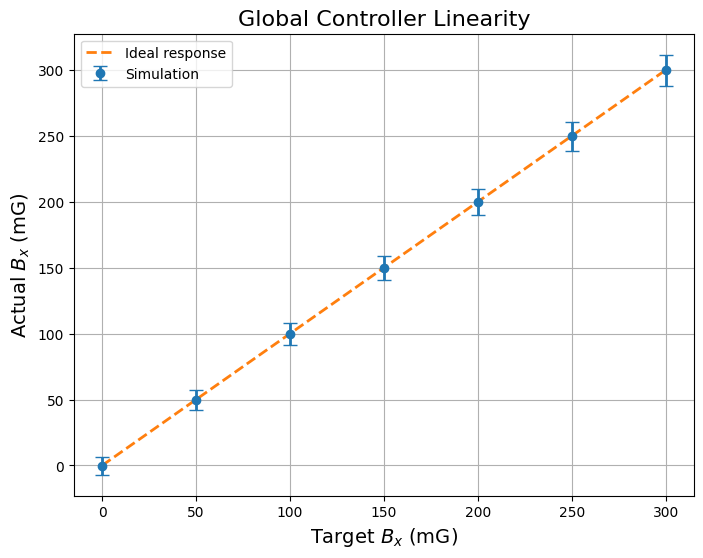

In [9]:
# ============================================================
# GLOBAL CONTROLLER LINEARITY
# ============================================================

plt.figure(

    figsize=(8,6)
)

# ------------------------------------------------------------
# ERROR BAR PLOT
# ------------------------------------------------------------

plt.errorbar(

    Bx_targets,

    Bx_actual_mean,

    yerr=Bx_actual_rms,

    fmt='o',

    capsize=5,

    linewidth=2,

    label='Simulation'
)

# ------------------------------------------------------------
# IDEAL RESPONSE
# ------------------------------------------------------------

plt.plot(

    Bx_targets,

    Bx_targets,

    '--',

    linewidth=2,

    label='Ideal response'
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

plt.xlabel(

    r'Target $B_x$ (mG)',

    fontsize=14
)

plt.ylabel(

    r'Actual $B_x$ (mG)',

    fontsize=14
)

plt.title(

    'Global Controller Linearity',

    fontsize=16
)

plt.grid(True)

plt.legend()

plt.show()

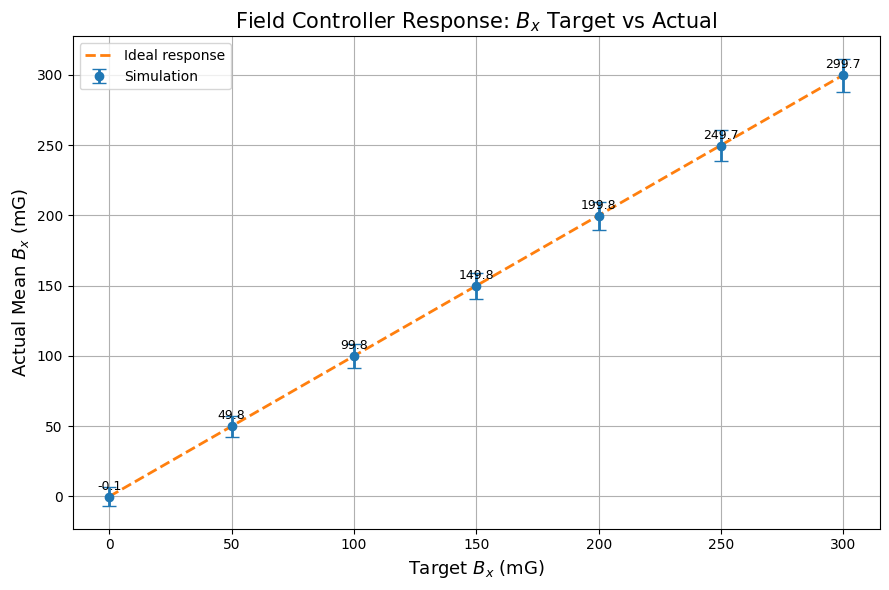

In [10]:
# ============================================================
# PLOT: TARGET Bx vs ACTUAL Bx
# WITH ERROR BARS + CENTRAL VALUES PRINTED
# ============================================================

plt.figure(figsize=(9,6))

# ------------------------------------------------------------
# ERROR BAR PLOT
# ------------------------------------------------------------

plt.errorbar(

    Bx_targets,

    Bx_actual_mean,

    yerr=Bx_actual_rms,

    fmt='o',

    capsize=5,

    linewidth=2,

    label='Simulation'
)

# ------------------------------------------------------------
# IDEAL RESPONSE LINE
# ------------------------------------------------------------

plt.plot(

    Bx_targets,

    Bx_targets,

    '--',

    linewidth=2,

    label='Ideal response'
)

# ------------------------------------------------------------
# PRINT CENTRAL VALUES
# ------------------------------------------------------------

for x, y in zip(Bx_targets, Bx_actual_mean):

    plt.text(

        x,

        y + 5,   # small offset upward

        f'{y:.1f}',

        fontsize=9,

        ha='center'
    )

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

plt.xlabel(

    r'Target $B_x$ (mG)',

    fontsize=13
)

plt.ylabel(

    r'Actual Mean $B_x$ (mG)',

    fontsize=13
)

plt.title(

    r'Field Controller Response: $B_x$ Target vs Actual',

    fontsize=15
)

# ------------------------------------------------------------
# GRID + LEGEND
# ------------------------------------------------------------

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()